In [1]:
# load librairies
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
import os
from os.path import join
import seaborn as sns
import statsmodels.api as sm
import scipy
import json
import statsmodels.formula.api as smf
from collections import defaultdict
from scipy.stats import wilcoxon, ttest_rel

from functions import utils, plotting, io, behav_analysis

In [2]:
# pick format to save figures : png for quick visualization, pdf for illustrator
save_as = 'png'
color_dict = {
    'DBS ON': '#20a39e', 
    'DBS OFF': '#ef5b5b', 
    'control': '#ffba49', 
    'preop': '#8E7DBE',
    'Session 1': "#206ea1", 
    'Session 2': "#5FA363", 
    }
visualize_by = 'subject' # pick whether to visualize by condition (DBS ON, DBS OFF, control) or by subject id


# 1. Select subjects, create color palette and load data #

In [3]:
# Use the Included or excluded.xlsx document:
onedrive_path = utils._get_onedrive_path()

working_path = os.path.dirname(os.getcwd())
results_path = join(working_path, "results")
behav_results_saving_path = join(results_path, "behav_results")
if not os.path.isdir(behav_results_saving_path):
    os.makedirs(behav_results_saving_path)

# read the json file containing the included and excluded subjects
# Open and read the JSON file
included_excluded_file = join(results_path, 'final_included_subjects.json')
with open(included_excluded_file, 'r') as file:
    included_subjects = json.load(file)    

In [ ]:
included_subjects

In [4]:
subject_colors = utils.create_color_palette(included_subjects)
utils.plot_color_palette(
    subject_colors = subject_colors,
    save_as='png', 
    saving_path=behav_results_saving_path
    )

['C003', 'C004', 'C006', 'C007', 'C008', 'C009', 'C010', 'C011', 'C012', 'C013', 'C014', 'C015', 'sub006', 'sub011', 'sub012', 'sub015', 'sub019', 'sub023', 'sub025', 'sub027', 'sub028', 'sub029', 'sub032', 'sub033']


In [5]:
# load excel files for all included subjects and extract stats
data = io.load_behav_data(included_subjects, onedrive_path)
stats = utils.extract_stats(data)

C003 mSST
C004 mSST
C006 mSST
C007 mSST
C008 mSST
C009 mSST
C010 mSST
C011 mSST
C012 mSST
C013 mSST
C014 mSST
C015 mSST
sub006 DBS ON mSST
sub006 DBS OFF mSST
sub011 DBS OFF mSST
sub011 DBS ON mSST
sub012 DBS ON mSST
sub012 DBS OFF mSST
sub015 DBS OFF mSST
sub015 DBS ON mSST
sub019 DBS ON mSST
sub019 DBS OFF mSST
sub023 DBS OFF mSST
sub023 DBS ON mSST
sub025 DBS ON mSST
sub025 DBS OFF mSST
sub027 DBS ON mSST
sub027 DBS OFF mSST
sub028 DBS OFF mSST
sub028 DBS ON mSST
sub029 DBS ON mSST
sub029 DBS OFF mSST
sub032 DBS ON mSST
sub032 DBS OFF mSST
sub033 DBS ON mSST
sub033 DBS OFF mSST


# 2. Get scales from 'WP3_rec_info.xlsx' and convert to panda dataframe containing all included subjects measures, save to excel #

In [6]:
# fetch excel file containing recording and subject information
excel_file = join(onedrive_path, 'WP3_rec_info.xlsx')
# select the relevant sheet called 'Subjects List'
subject_info_df = pd.read_excel(excel_file, sheet_name='Subjects List')
control_info_df = pd.read_excel(excel_file, sheet_name='Controls List')

# get session order and save it to 'session_info.txt'
behav_analysis.get_session_order(
    included_subjects = included_subjects,
    subject_info_df = subject_info_df,
    behav_results_saving_path = behav_results_saving_path
)


6 subjects started with first session in OFF condition
6 subjects started with first session in ON condition


In [7]:
# get the behavioral scores for all scales of interest
scale_names = ['UPDRS_ON', 'UPDRS_OFF', 'MOCA', 'BDI', 'SAS', 'BIS_TOTAL', 'BIS_nonplanning', 'BIS_motor', 'BIS_attentional', 'OCI_TOTAL', 'OCI_washing', 'OCI_obsessing', 'OCI_hoarding', 'OCI_ordering', 'OCI_checking', 'OCI_neutralizing']
subs = [subj.split(' ')[0] for subj in included_subjects]
# remove duplicates in subs and order the list:
subs = sorted(list(set(subs)))

sub_scale_dict = {}
for sub in subs:
    if sub.startswith('C'):
        sub_line = control_info_df[control_info_df['StudyCode'] == sub]
    else:
        sub_line = subject_info_df[subject_info_df['StudyCode'] == sub]
    scale_dict = {}
    for scale in scale_names:
        if scale in sub_line.columns:
            scale_value = sub_line[scale].values[0]
        else:
            scale_value = None
        scale_dict[scale] = scale_value
    sub_scale_dict[sub] = scale_dict    

In [8]:
# save sub_scale_dict to an excel file:
sub_scale_df = pd.DataFrame.from_dict(sub_scale_dict, orient='index')
sub_scale_df.to_excel(join(behav_results_saving_path, 'sub_scale_dict.xlsx'))


In [ ]:
sub_scale_df

# 3. Visualize results from scales #

## 3.1. Visualize scores for each scale, per subject or per condition ##

When plotting by condition, a two-sided Mann-Whitney test is used to compare Healthy control and PD patients (non-parametric and independent measures).
Except for UPDRS, for which the test used is a two-sided Wilcoxon signed-rank test because (non-parametric but dependent/repeated measures from the same patients: comaprison ON versus OFF)

Visualizing UPDRS_ON scores for all subjects


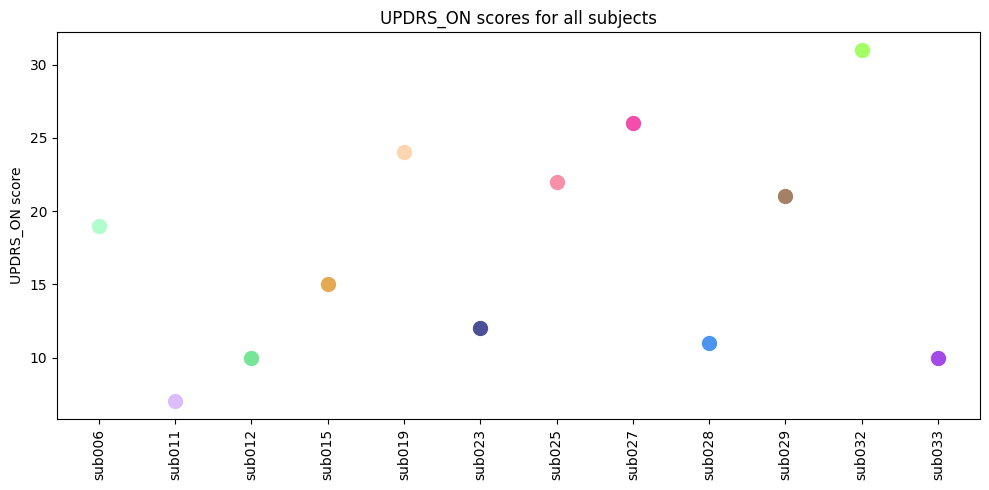

Visualizing UPDRS_OFF scores for all subjects


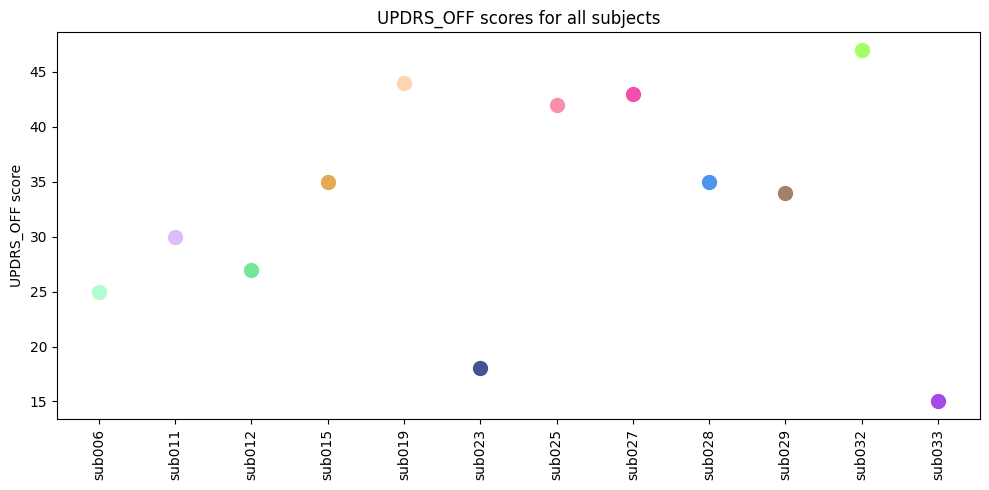

Visualizing MOCA scores for all subjects


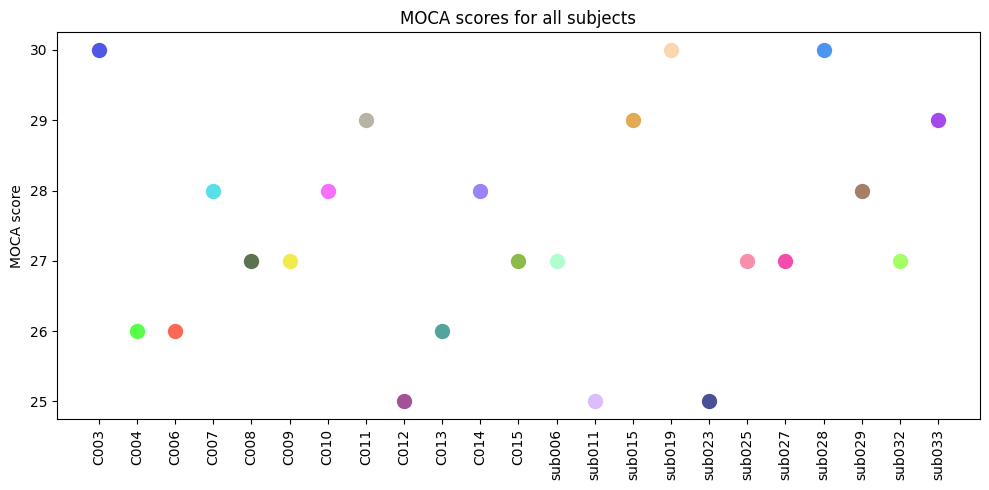

Visualizing BDI scores for all subjects


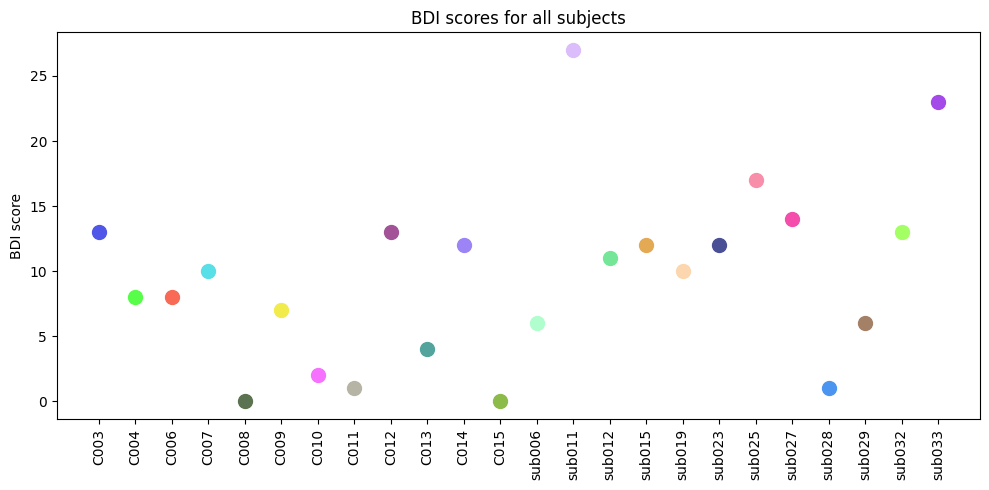

Visualizing SAS scores for all subjects


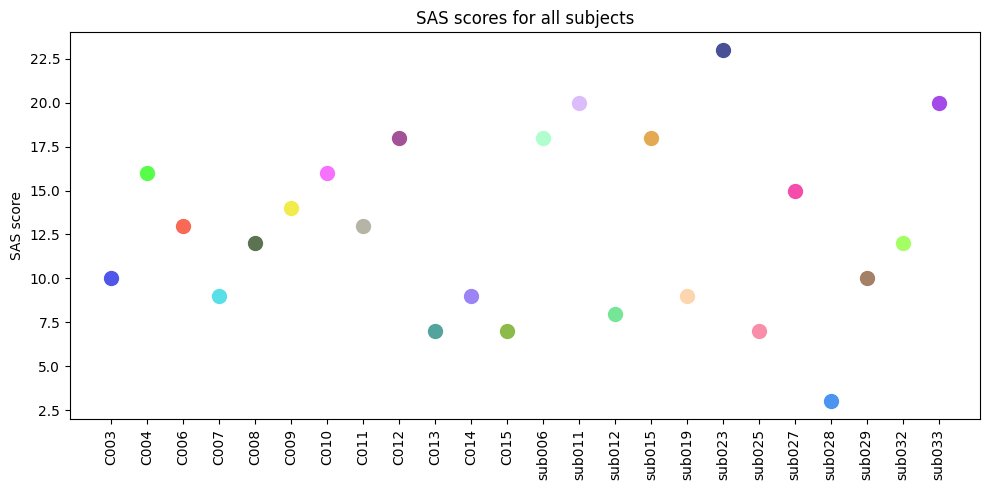

Visualizing BIS_TOTAL scores for all subjects


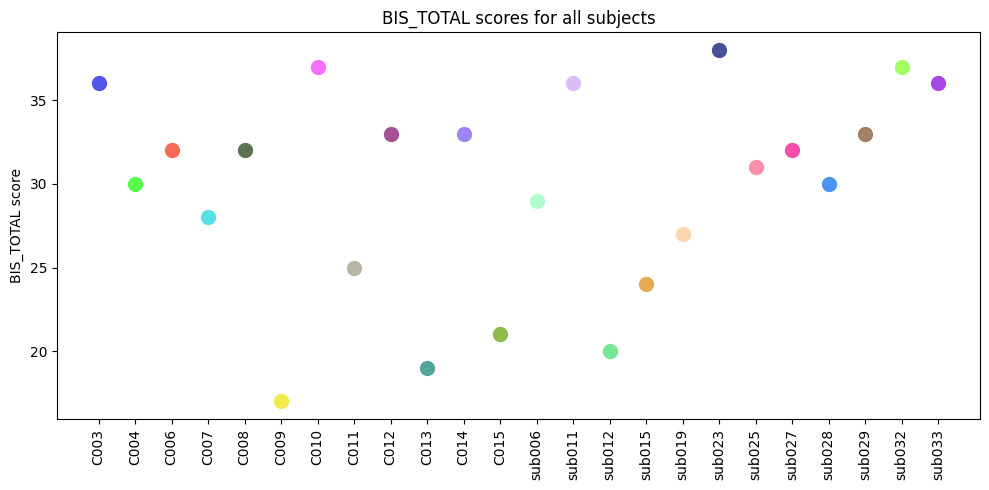

Visualizing BIS_nonplanning scores for all subjects


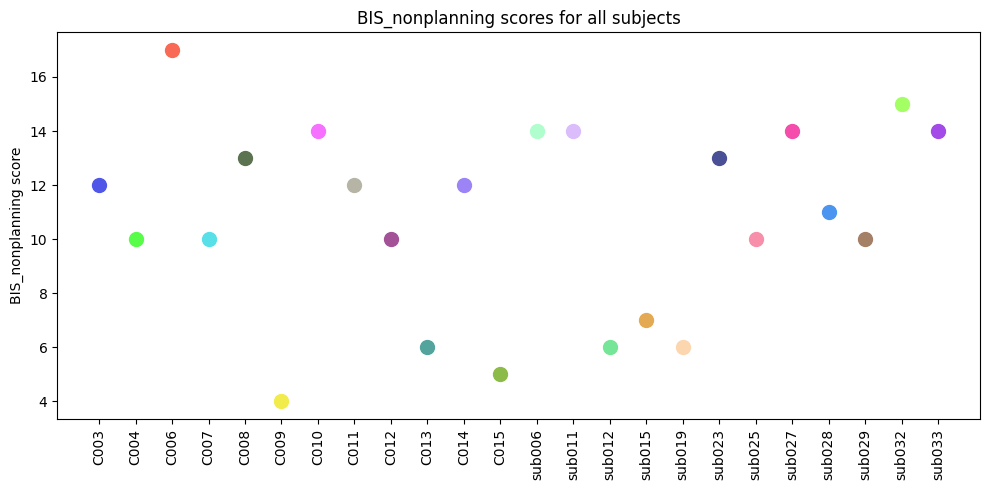

Visualizing BIS_motor scores for all subjects


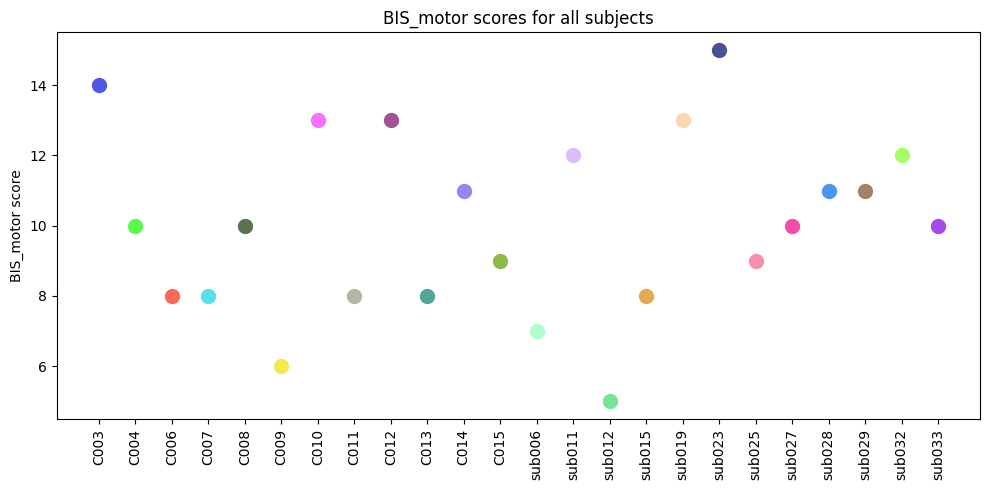

Visualizing BIS_attentional scores for all subjects


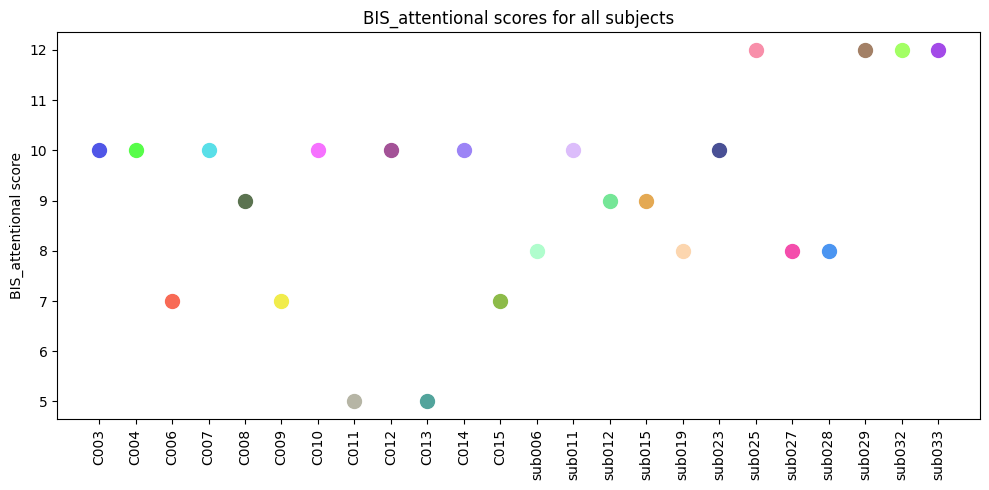

Visualizing OCI_TOTAL scores for all subjects


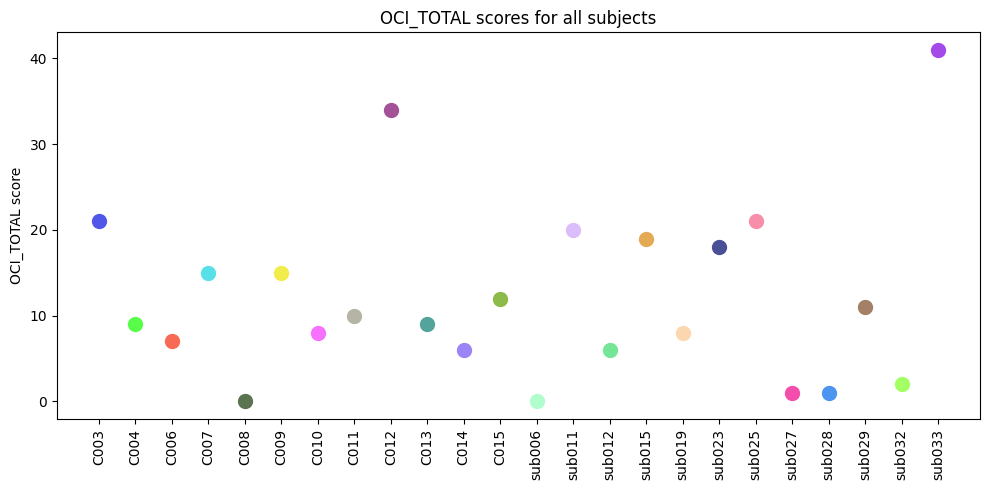

Visualizing OCI_washing scores for all subjects


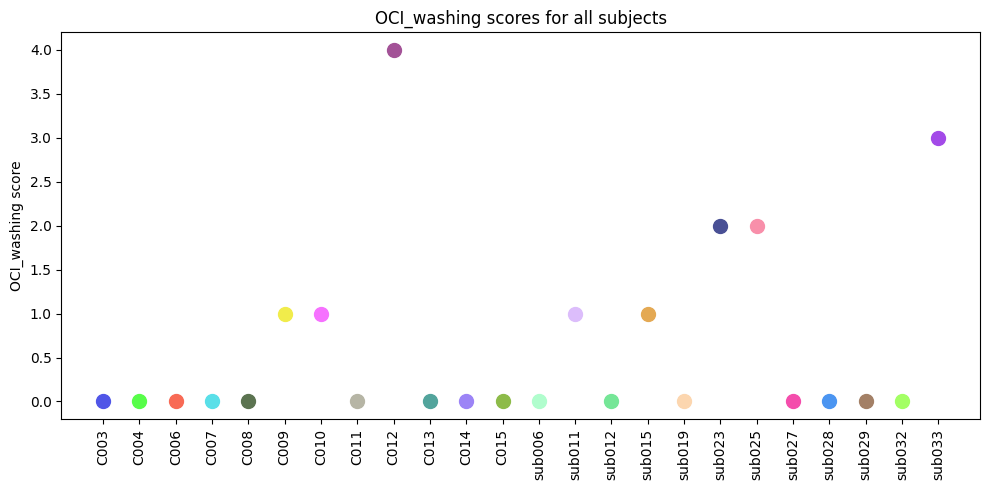

Visualizing OCI_obsessing scores for all subjects


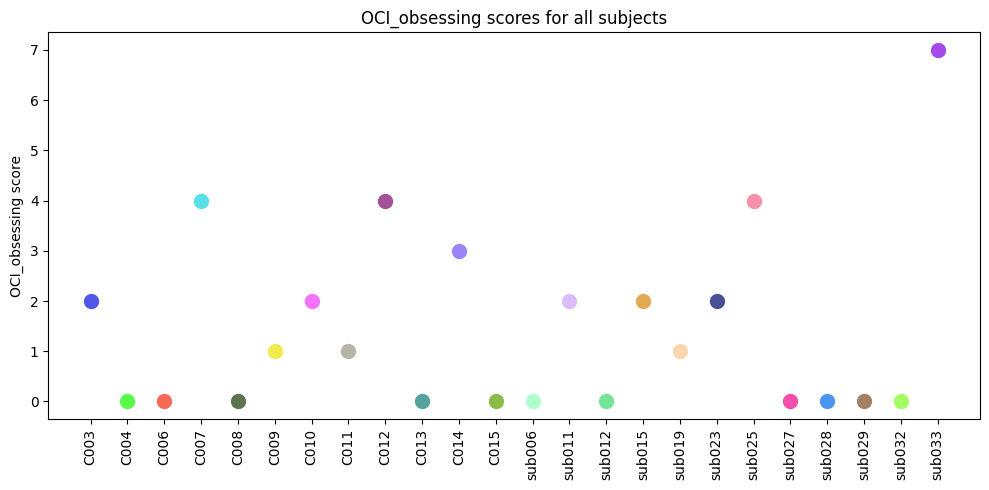

Visualizing OCI_hoarding scores for all subjects


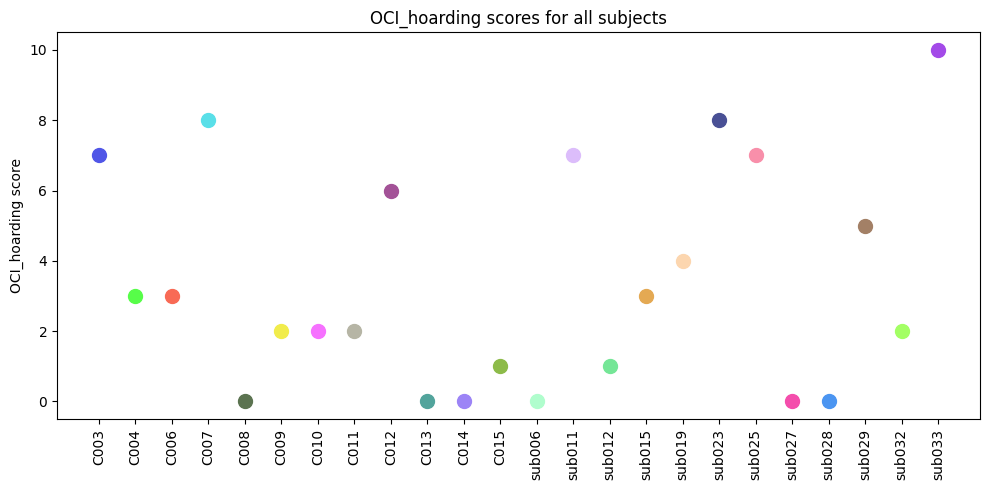

Visualizing OCI_ordering scores for all subjects


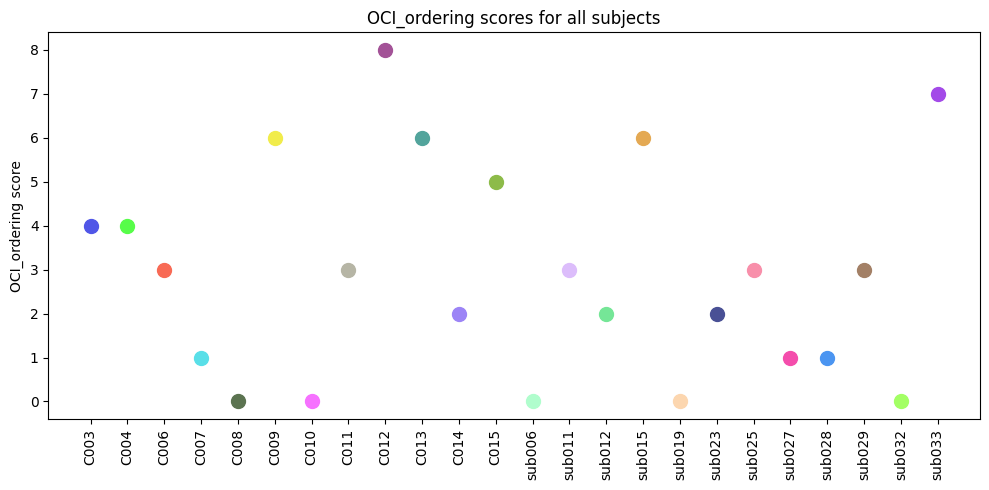

Visualizing OCI_checking scores for all subjects


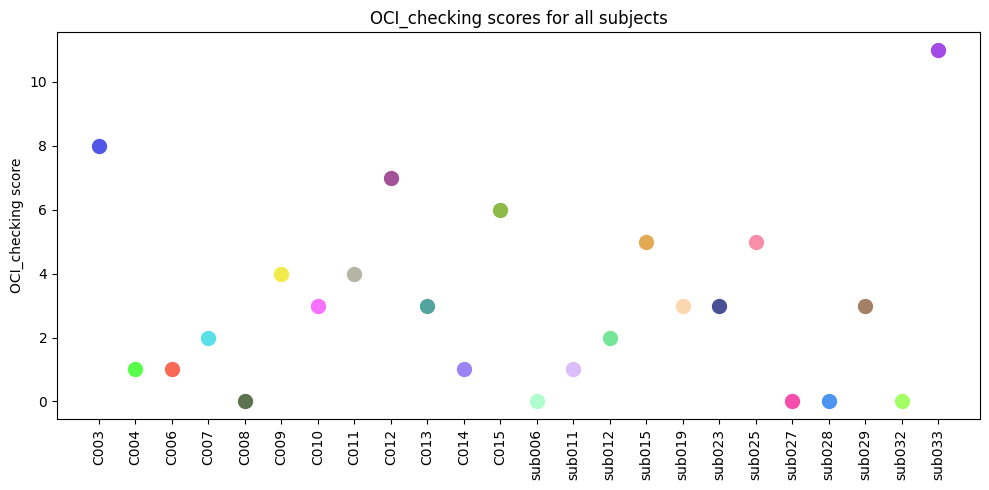

Visualizing OCI_neutralizing scores for all subjects


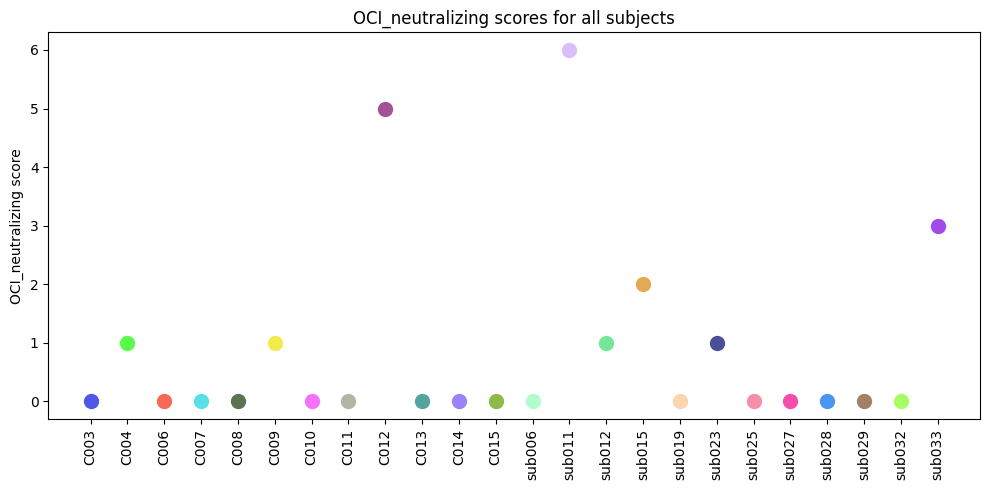

MOCA: Mann–Whitney U test
Patients n=11, Controls n=12
U = 75.50, p = 0.5717


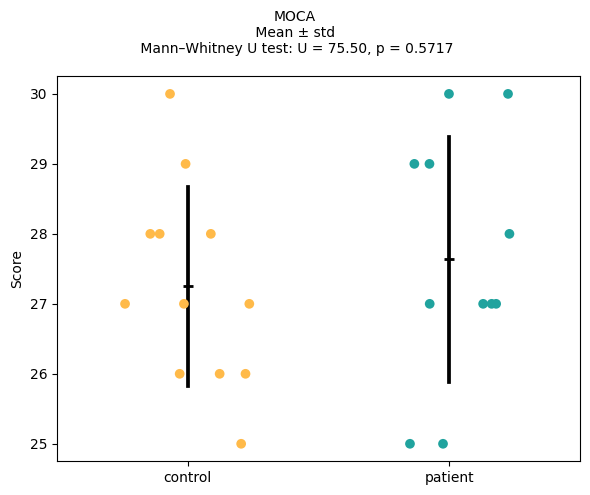

BDI: Mann–Whitney U test
Patients n=12, Controls n=12
U = 108.00, p = 0.0398


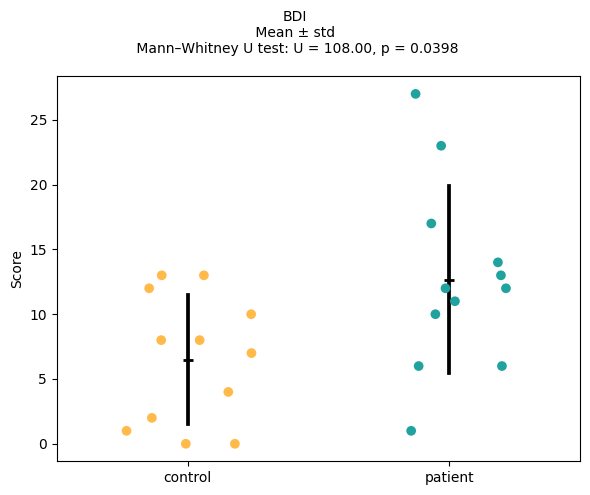

SAS: Mann–Whitney U test
Patients n=12, Controls n=12
U = 84.00, p = 0.5051


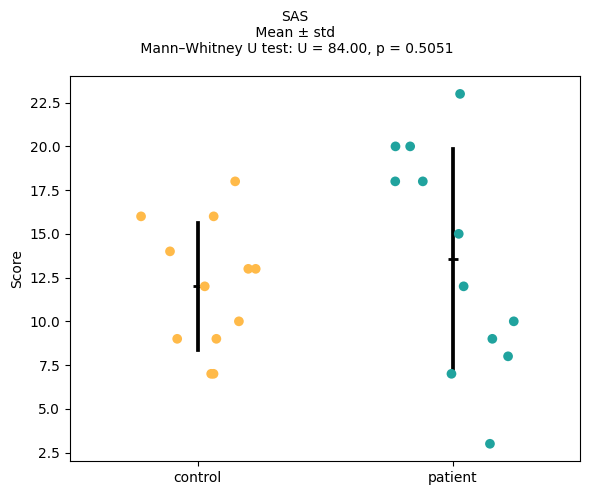

BIS_TOTAL: Mann–Whitney U test
Patients n=12, Controls n=12
U = 86.00, p = 0.4343


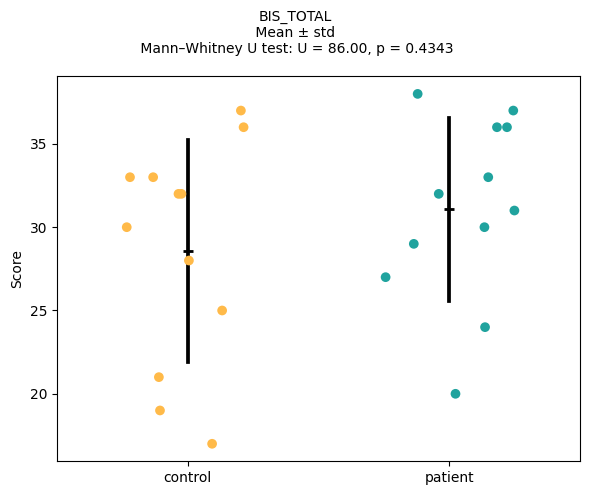

BIS_nonplanning: Mann–Whitney U test
Patients n=12, Controls n=12
U = 85.50, p = 0.4480


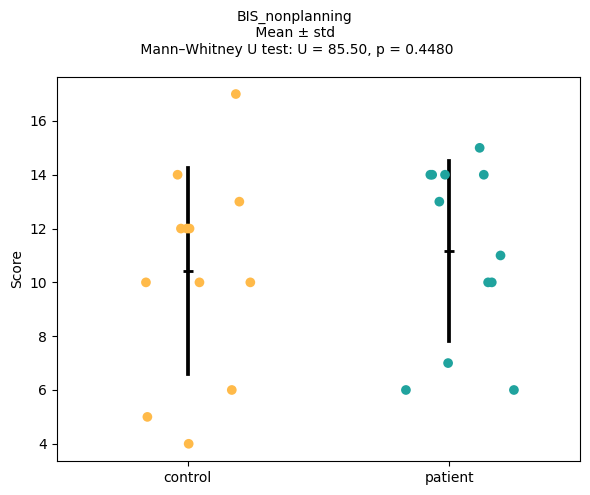

BIS_motor: Mann–Whitney U test
Patients n=12, Controls n=12
U = 80.50, p = 0.6413


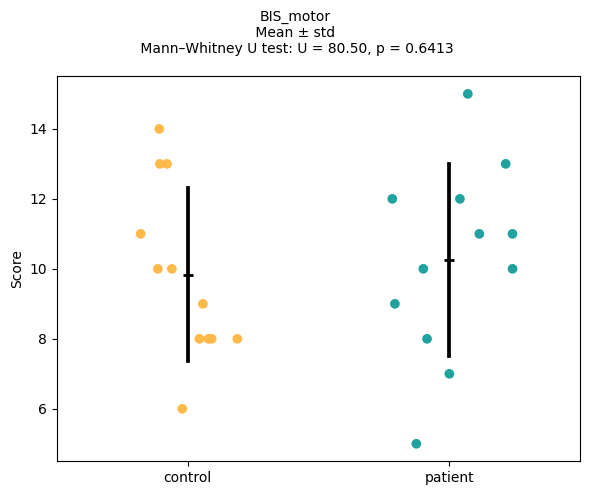

BIS_attentional: Mann–Whitney U test
Patients n=12, Controls n=12
U = 97.00, p = 0.1469


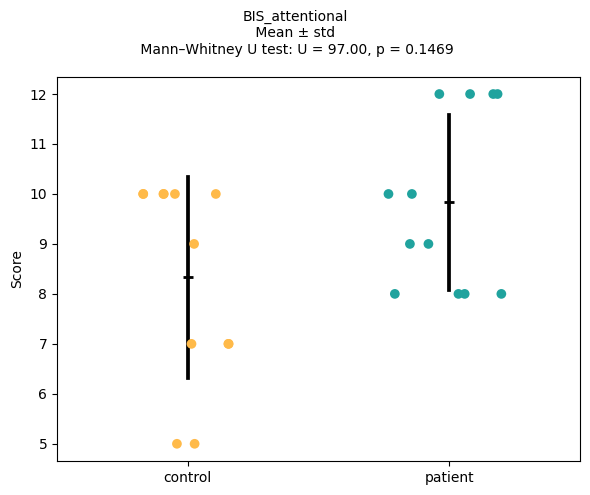

OCI_TOTAL: Mann–Whitney U test
Patients n=12, Controls n=12
U = 68.00, p = 0.8396


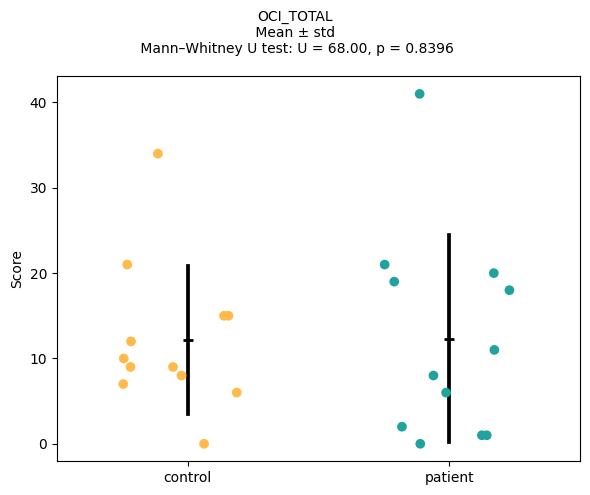

OCI_washing: Mann–Whitney U test
Patients n=12, Controls n=12
U = 84.50, p = 0.4075


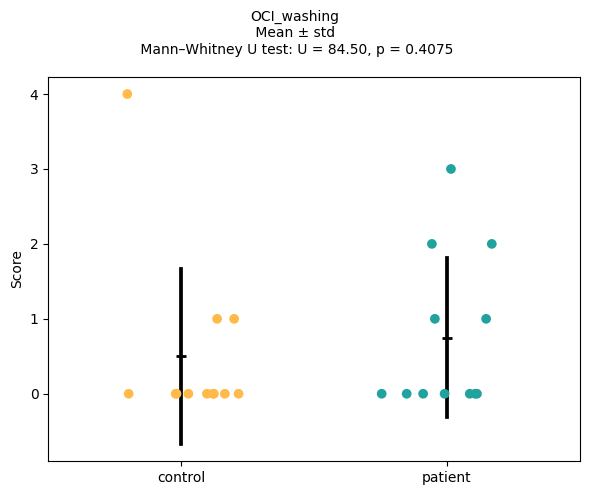

OCI_obsessing: Mann–Whitney U test
Patients n=12, Controls n=12
U = 68.00, p = 0.8306


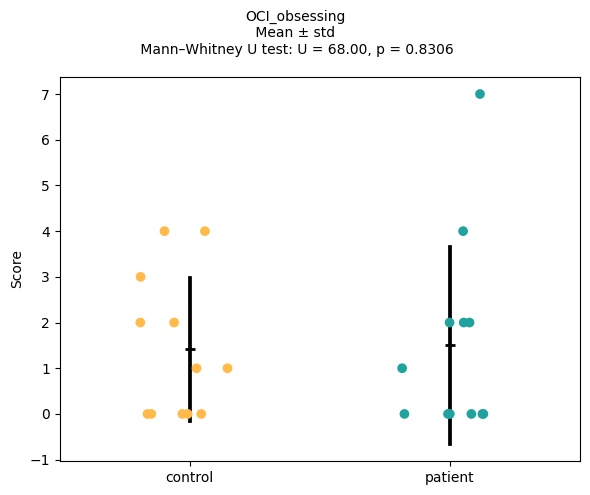

OCI_hoarding: Mann–Whitney U test
Patients n=12, Controls n=12
U = 84.00, p = 0.5016


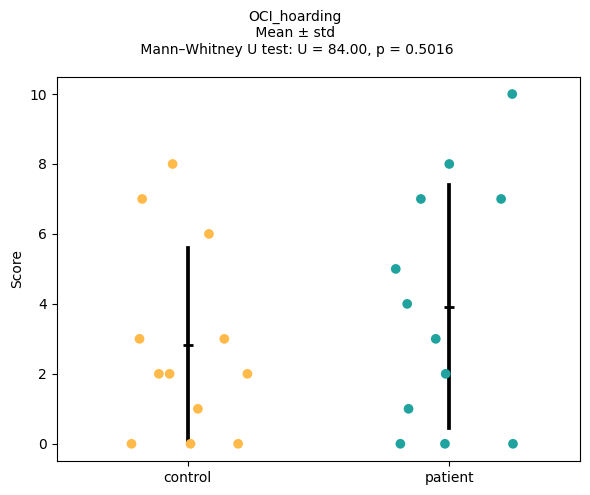

OCI_ordering: Mann–Whitney U test
Patients n=12, Controls n=12
U = 51.00, p = 0.2311


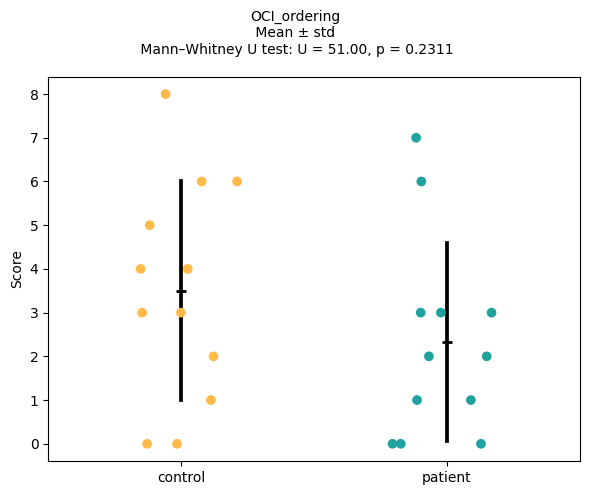

OCI_checking: Mann–Whitney U test
Patients n=12, Controls n=12
U = 57.00, p = 0.3970


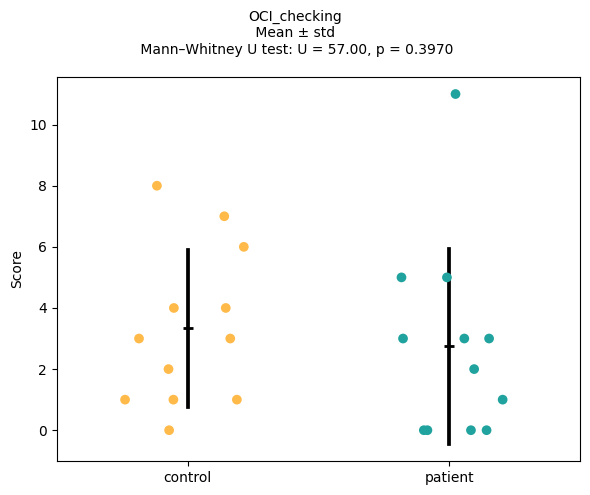

OCI_neutralizing: Mann–Whitney U test
Patients n=12, Controls n=12
U = 85.50, p = 0.3697


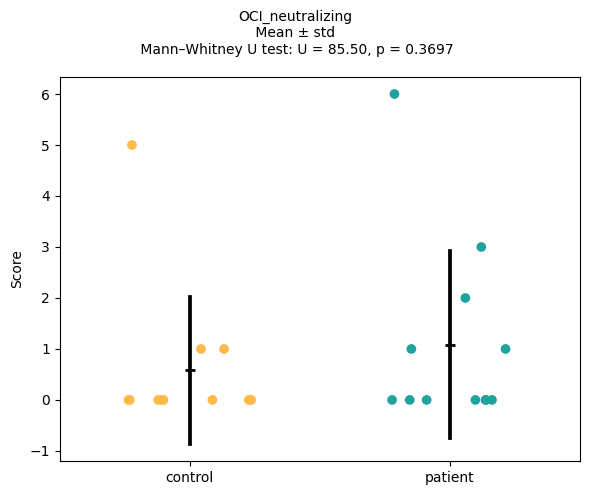

In [9]:
temp_save = join(behav_results_saving_path, "scales")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)

for viz in ['subject', 'condition']:
    behav_analysis.visualize_scales_scores(
        scale_names = scale_names,
        sub_scale_dict = sub_scale_dict,
        subs = subs,
        subject_colors = subject_colors,
    color_dict = color_dict,
    visualize_by = viz,
    saving_path = temp_save,
    save_as = save_as,
    show_plot = True
    )

UPDRS ON vs OFF: Wilcoxon signed-rank test
n = 12
Statistic = 0.00, p = 0.0005
OFF median: 34.5
ON median: 17.0


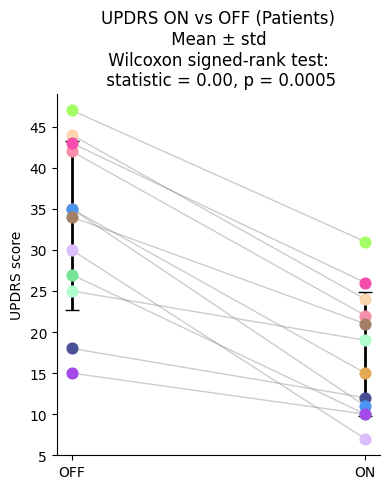

UPDRS ON vs OFF: Wilcoxon signed-rank test
n = 12
Statistic = 0.00, p = 0.0005
OFF median: 34.5
ON median: 17.0


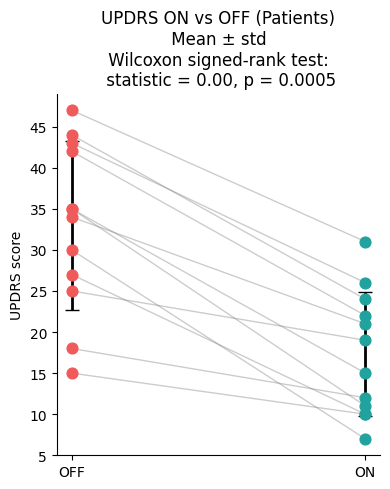

In [10]:
temp_save = join(behav_results_saving_path, "scales")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)

for viz in ['subject', 'condition']:
    behav_analysis.visualize_updrs_scores(
    sub_scale_dict = sub_scale_dict, 
    subject_colors = subject_colors,
    color_dict = color_dict, 
    colored_by = viz,
    saving_path = temp_save, 
    save_as = save_as,
    show_plot = True
    )

## 3.2. Correlate scores between 2 scales and visualize ##

"Attentional impulsiveness is defined as an inability to focus attention or concentrate. Motor Impulsiveness involves acting without thinking, and Non-Planning Impulsiveness involves a lack of ‘‘futuring” or forethought (Barratt, 1985)." --> based on the original BIS, which contains 30 items. We use the kurzversion (only 15 items).

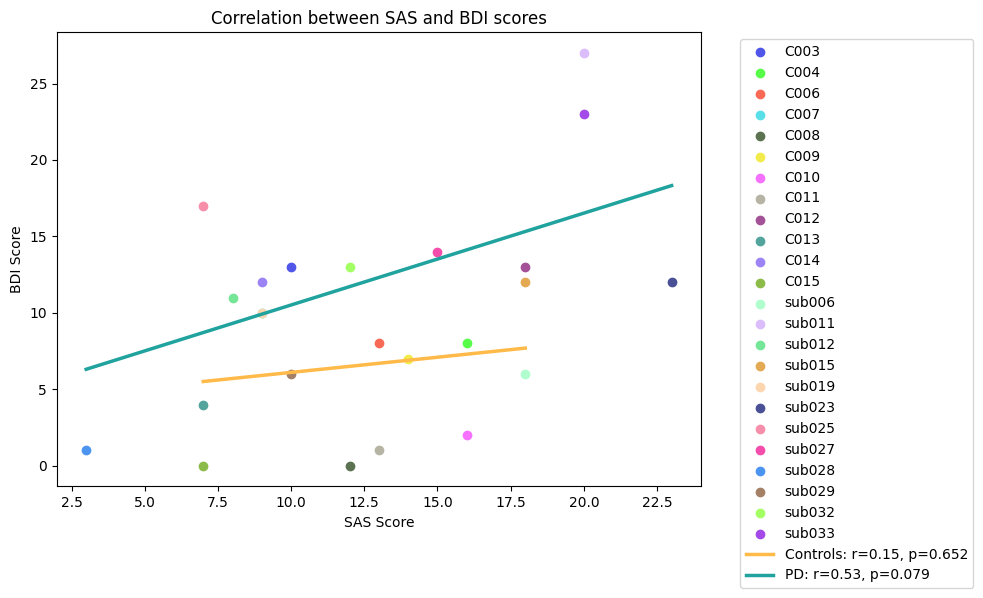

In [20]:
temp_save = join(behav_results_saving_path, "scales")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)  
      
behav_analysis.correlate_two_scales(
    scale_1 = 'SAS',
    scale_2 = 'BDI',
    sub_scale_dict = sub_scale_dict,
    subject_colors = subject_colors,
    color_dict = color_dict,
    saving_path = temp_save,
    save_as = save_as,
    show_plot = True
)

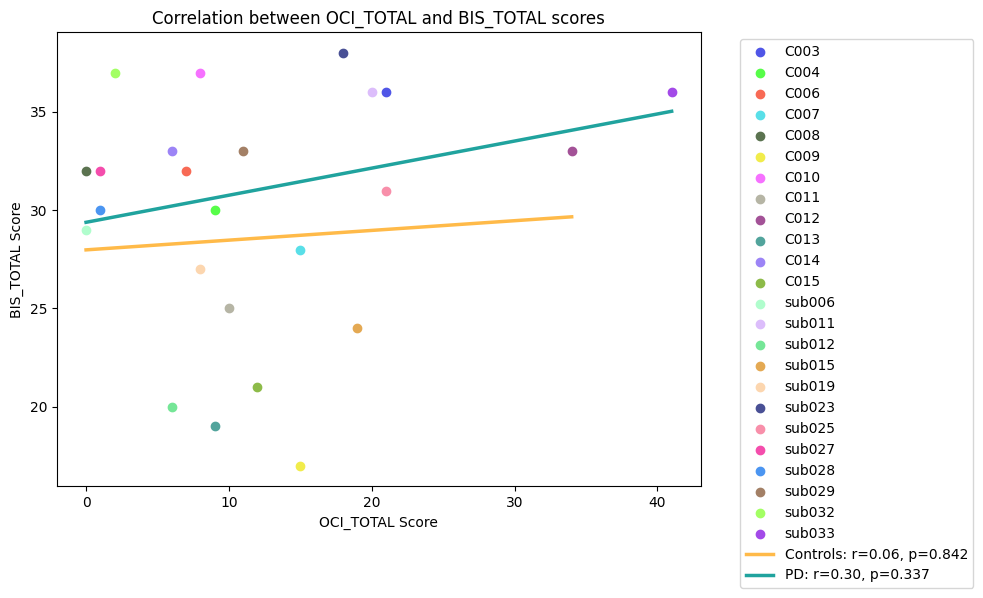

In [21]:
temp_save = join(behav_results_saving_path, "scales")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)  

behav_analysis.correlate_two_scales(
    scale_1 = 'OCI_TOTAL',
    scale_2 = 'BIS_TOTAL',
    sub_scale_dict = sub_scale_dict,
    subject_colors = subject_colors,
    color_dict = color_dict,
    saving_path = temp_save,
    save_as = save_as,
    show_plot = True
)

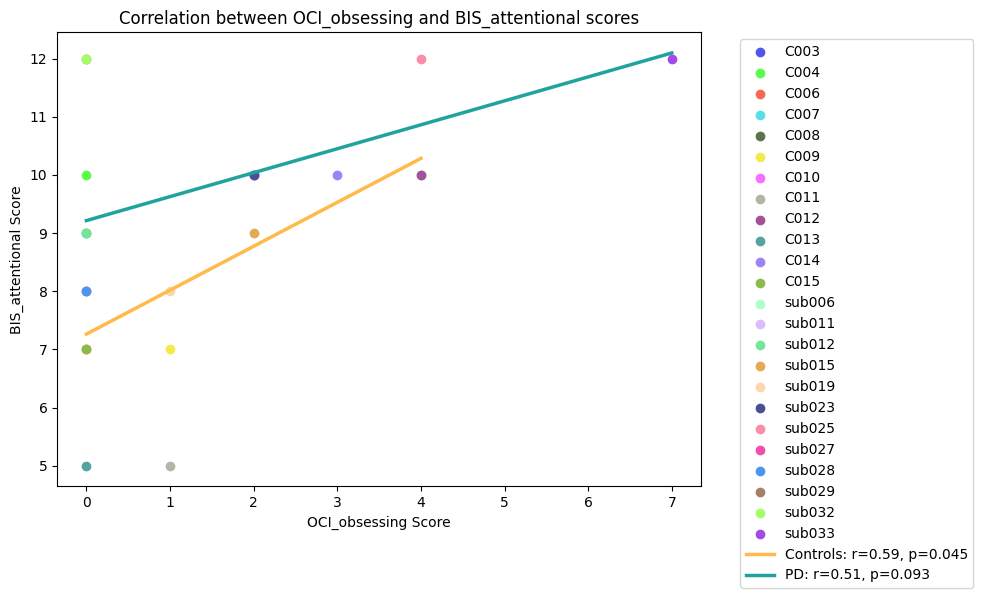

In [ ]:
temp_save = join(behav_results_saving_path, "scales")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)  

behav_analysis.correlate_two_scales(
    scale_1 = 'OCI_obsessing',
    scale_2 = 'BIS_attentional',
    sub_scale_dict = sub_scale_dict,
    subject_colors = subject_colors,
    color_dict = color_dict,
    saving_path = temp_save,
    save_as = save_as,
    show_plot = True
)

# idea from https://pmc.ncbi.nlm.nih.gov/articles/PMC11054498/

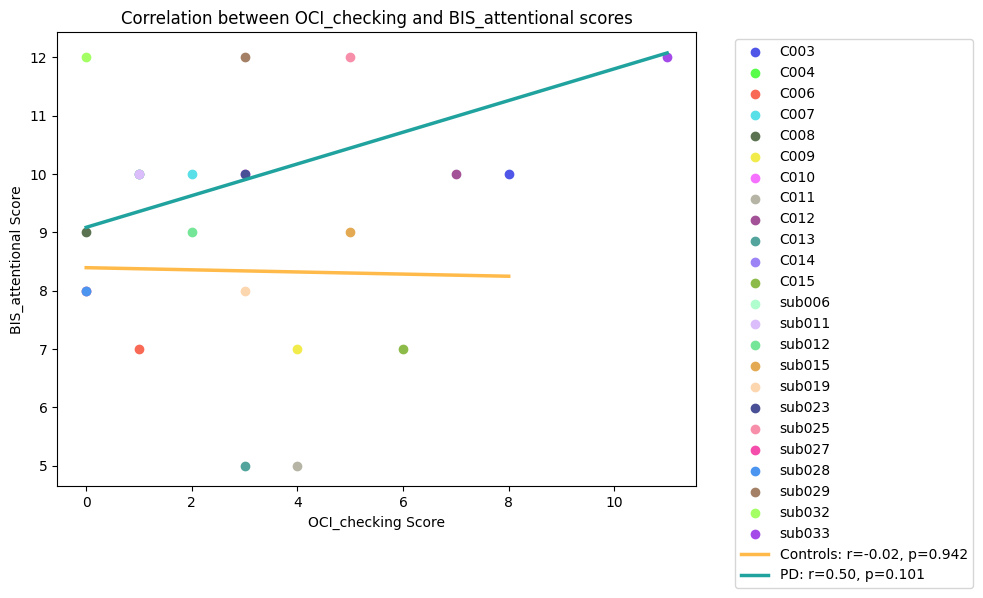

In [25]:
temp_save = join(behav_results_saving_path, "scales")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)  

behav_analysis.correlate_two_scales(
    scale_1 = 'OCI_checking',
    scale_2 = 'BIS_attentional',
    sub_scale_dict = sub_scale_dict,
    subject_colors = subject_colors,
    color_dict = color_dict,
    saving_path = temp_save,
    save_as = save_as,
    show_plot = True
)

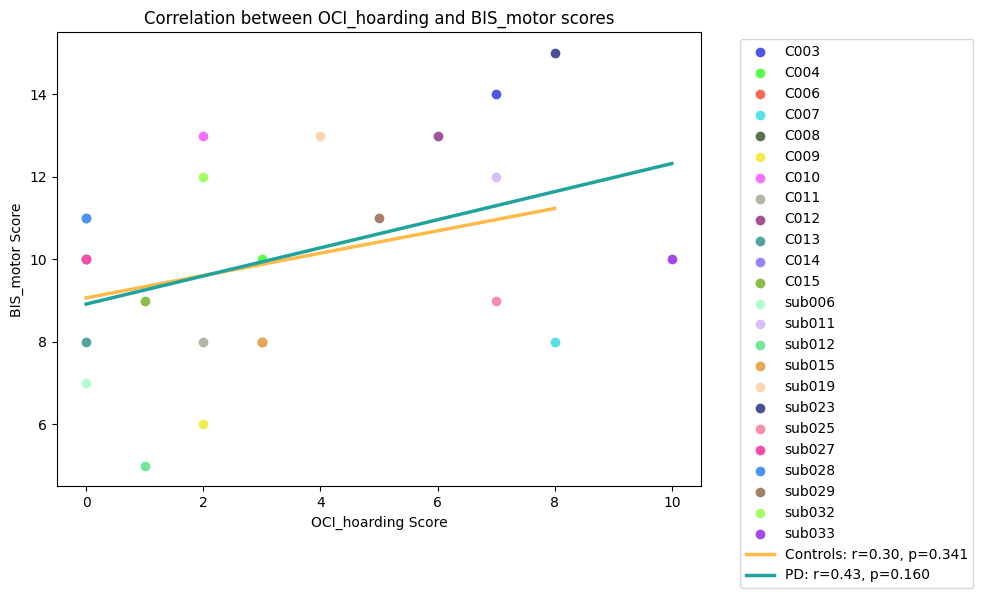

In [23]:
temp_save = join(behav_results_saving_path, "scales")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)  

behav_analysis.correlate_two_scales(
    scale_1 = 'OCI_hoarding',
    scale_2 = 'BIS_motor',
    sub_scale_dict = sub_scale_dict,
    subject_colors = subject_colors,
    color_dict = color_dict,
    saving_path = temp_save,
    save_as = save_as,
    show_plot = True
)